In [5]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import pandas as pd

def histogramnice(df,storeloc, title):
    # ── data ──────────────────────────────────────────────────────────────────────
    dfplot = df.copy()

    # ── palette ───────────────────────────────────────────────────────────────────
    BLUE      = "#2D6A9F"   # bar fill
    BLUE_EDGE = "#1A4872"   # bar edge
    STAT_BG   = "#EFF4FA"   # stats box background
    TEXT      = "#1C2B3A"   # primary text
    GRID      = "#D6E3EF"   # gridlines

    # ── layout ────────────────────────────────────────────────────────────────────
    n_vars = len(dfplot.columns)
    ncols  = 3
    nrows  = int(np.ceil(n_vars / ncols))

    fig, axes = plt.subplots(nrows, ncols, figsize=(13, 8))
    axes_flat  = axes.flatten()

    fig.patch.set_facecolor("white")
    fig.suptitle(title, fontsize=14, fontweight="bold",
                color=TEXT, y=1.01)

    for i, col in enumerate(dfplot.columns):
        ax   = axes_flat[i]
        data = dfplot[col].dropna()

        # histogram
        ax.hist(data, bins=40, color=BLUE, edgecolor=BLUE_EDGE,
                linewidth=0.4, alpha=0.88)

        # subtle grid (behind bars)
        ax.set_axisbelow(True)
        ax.yaxis.grid(True, color=GRID, linewidth=0.6, linestyle="--")
        ax.xaxis.grid(False)

        # spines
        for spine in ["top", "right"]:
            ax.spines[spine].set_visible(False)
        for spine in ["left", "bottom"]:
            ax.spines[spine].set_color(GRID)

        # title & tick style
        ax.set_title(col, fontsize=10, fontweight="semibold", color=TEXT, pad=6)
        ax.tick_params(axis="both", labelsize=7.5, colors=TEXT, length=3)
        ax.yaxis.set_major_formatter(mticker.FuncFormatter(
            lambda v, _: f"{int(v):,}" if v >= 1000 else f"{int(v)}"))

        # ── stats box ─────────────────────────────────────────────────────────────
        stats = {
            "Min":    data.min(),
            "Max":    data.max(),
            "Median": data.median(),
            "Mean":   data.mean(),
            "Std":    data.std(),
        }

        # choose sensible decimal places per variable
        decimals = 1 if col in ("Temperature", "Precipitation") else 2
        lines = "\n".join(
            f"{k}: {v:>{8}.{decimals}f}" for k, v in stats.items()
        )

        ax.text(0.97, 0.97, lines,
                transform=ax.transAxes,
                va="top", ha="right",
                fontsize=7,
                fontfamily="monospace",
                color=TEXT,
                bbox=dict(boxstyle="round,pad=0.35", facecolor=STAT_BG,
                        edgecolor=BLUE_EDGE, linewidth=0.6, alpha=0.9))

        # vertical lines for mean & median
        ax.axvline(data.mean(),   color="#E05A2B", linewidth=1.2,
                linestyle="--", label="Mean")
        ax.axvline(data.median(), color="#2BAE66", linewidth=1.2,
                linestyle=":",  label="Median")

        if i == 0:
            ax.legend(fontsize=7, framealpha=0.7,
                    loc="upper left", handlelength=1.5)

    # hide any unused subplot slots
    for j in range(i + 1, len(axes_flat)):
        axes_flat[j].set_visible(False)

    plt.tight_layout(h_pad=2.5, w_pad=2.0)
    plt.savefig(storeloc, dpi=150, bbox_inches="tight",
                facecolor="white")
    plt.show()

    return 

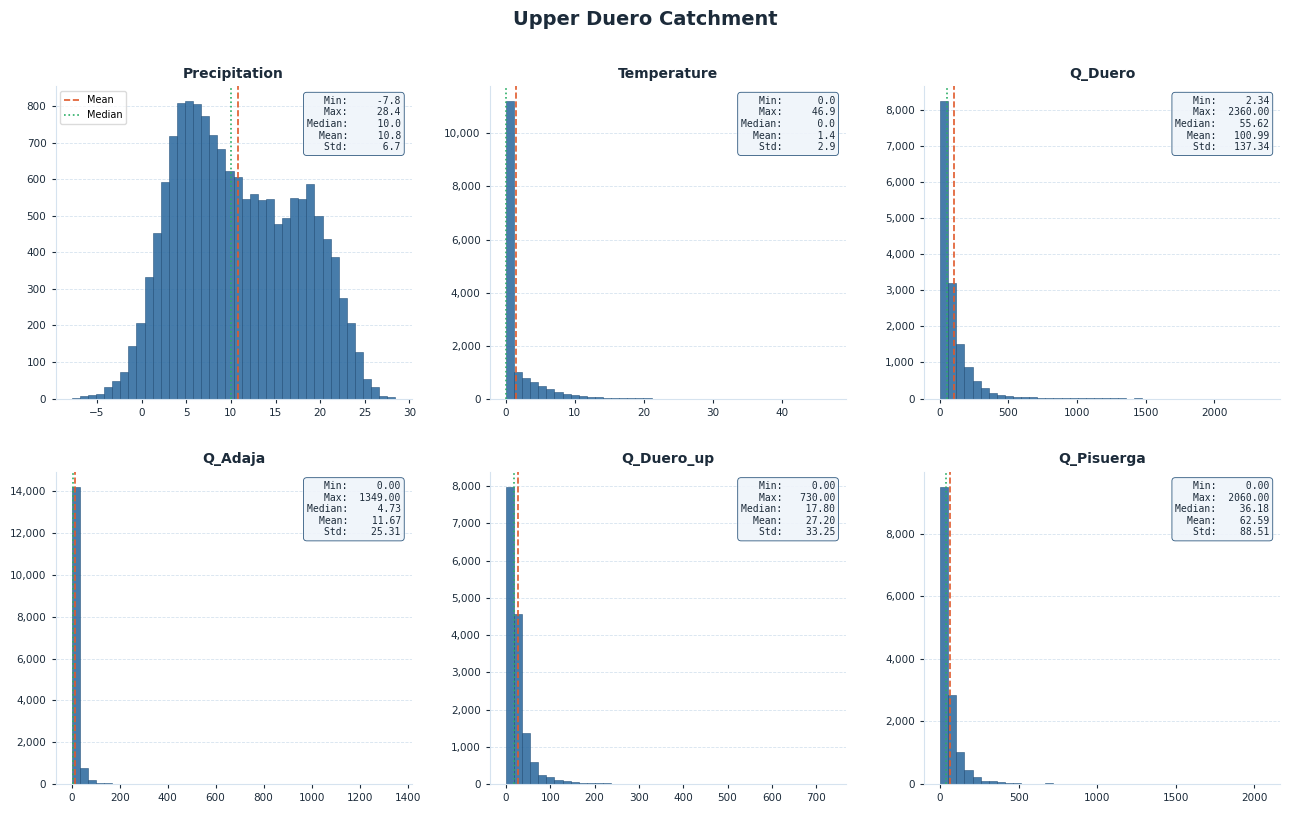

In [9]:
df1 = pd.read_pickle("Data/DueroData.pkl")
df1.columns = ["Precipitation", "Temperature", "Q_Duero", "Q_Adaja",
                    "Q_Duero_up", "Q_Pisuerga"]

histogramnice(df1, "HistogramDuero.png", "Upper Duero Catchment")

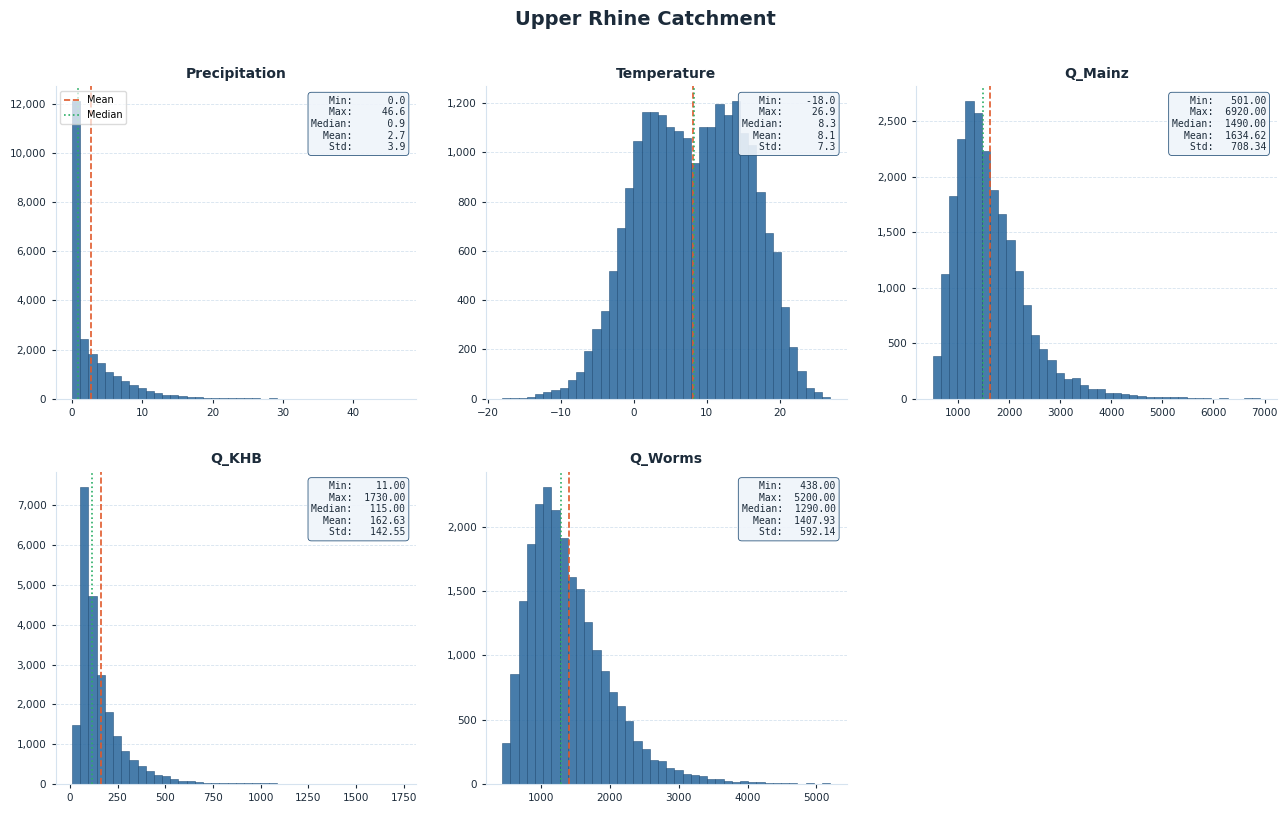

In [3]:
df2 = pd.read_pickle("Data/RijnData.pkl")
df2.columns = ["Precipitation", "Temperature", "Q_Mainz", "Q_KHB" ,"Q_Worms"]

histogramnice(df2, "HistogramRhine.png", "Upper Rhine Catchment")

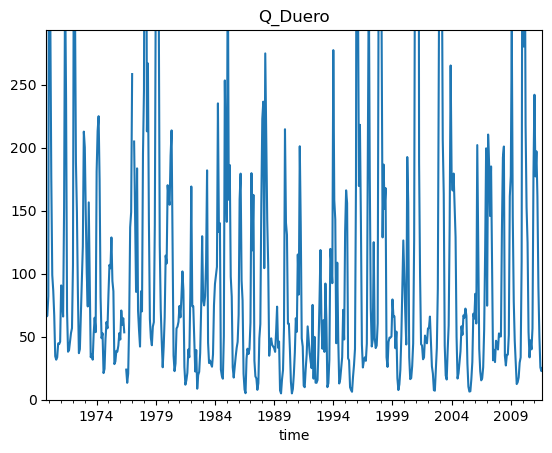

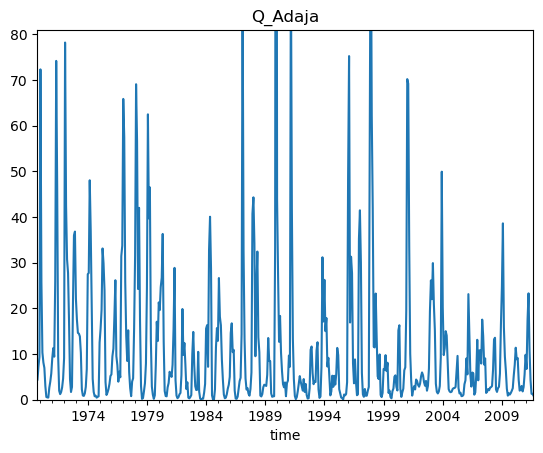

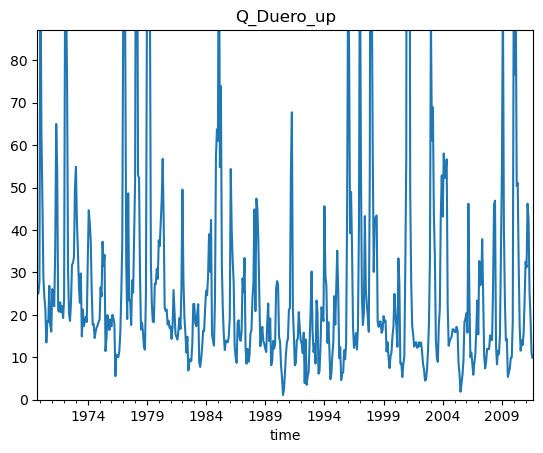

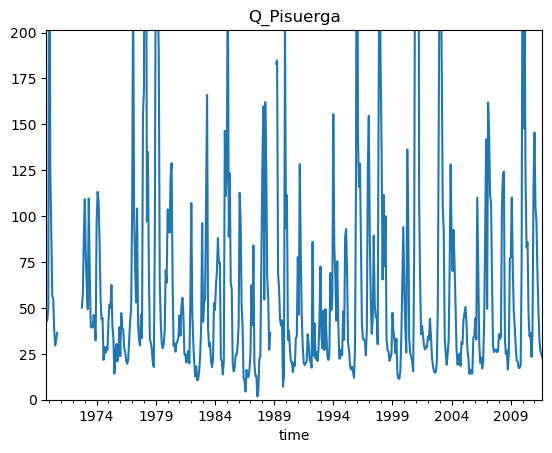

In [10]:
for column in df1.columns[2:]:
    plt.figure()
    monthlymean = df1[column].resample("ME").mean()


    ax = monthlymean.plot()
    ax.set_ylim((0,monthlymean.max()/3))
    ax.set_title(column)